# Linear Regression 

Linear Regression is a supervised machine learning algorithm used to model
the relationship between one or more independent variables and a continuous
dependent variable.

In this notebook, Linear Regression will be implemented completely from scratch
using Python and NumPy without using Scikit-Learn for the actual model.

### Learning Objectives

- Understand the mathematics behind Linear Regression
- Implement Linear Regression using Gradient Descent
- Implement prediction functionality
- Implement Mean Squared Error
- Visualize the learning process
- Evaluate the model
- Compare the implementation with Scikit-Learn

## 1. Mathematical Intuition

The basic Linear Regression equation is:

$$
y = wx + b
$$

where:

- $x$ = input feature
- $w$ = weight
- $b$ = bias
- $y$ = predicted output

For multiple features:

$$
\hat{y} = Xw + b
$$

The objective is to find values of $w$ and $b$ that minimize the prediction
error.

We use Mean Squared Error (MSE) as the loss function:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Gradient Descent is then used to update the parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=20,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 1)
y shape: (200,)


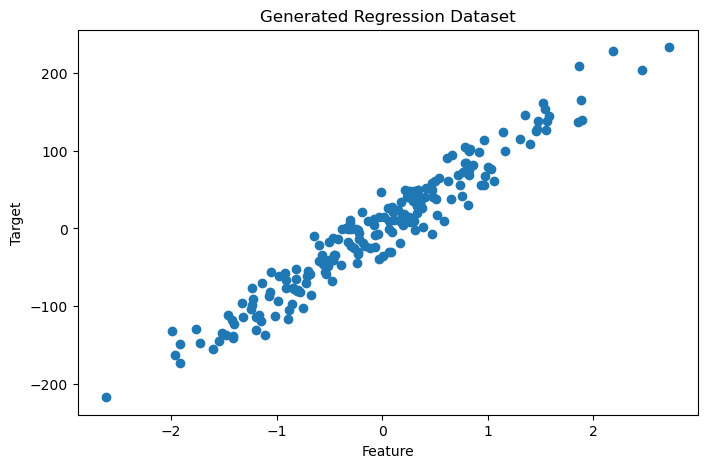

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Generated Regression Dataset")

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [5]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):

            # Predictions
            y_pred = np.dot(X, self.weights) + self.bias

            # Calculate error
            error = y_pred - y

            # Calculate gradients
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate loss
            mse = np.mean(error ** 2)
            self.loss_history.append(mse)

        return self

    def predict(self, X):

        return np.dot(X, self.weights) + self.bias

In [6]:
model = LinearRegressionScratch(
    learning_rate=0.01,
    iterations=1000
)

In [7]:
model.fit(X_train, y_train)

In [8]:
print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [86.51153778]
Bias: 2.446101966377654


In [9]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[  70.08280087   28.13870274 -120.81105457    8.37759035  -77.09470241
   70.87949214  -23.60284177  -22.78877289 -167.08797399 -105.32467545]


In [10]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Squared Error: 437.5498717360177
Mean Absolute Error: 16.04054114405642
R² Score: 0.9449706567825913


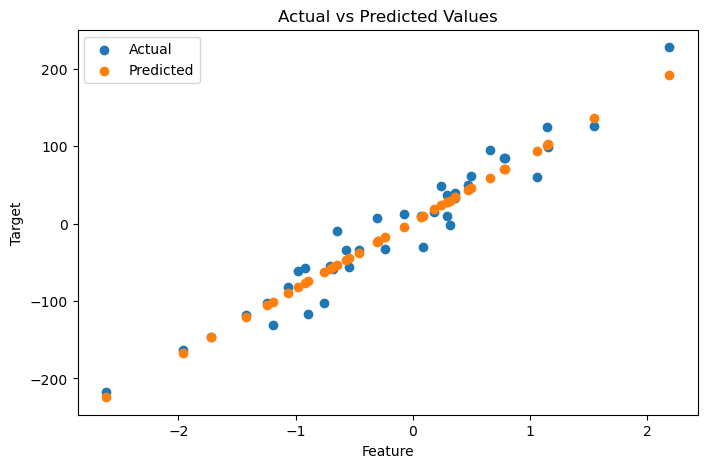

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual")

plt.scatter(X_test, y_pred, label="Predicted")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Actual vs Predicted Values")

plt.legend()
plt.show()

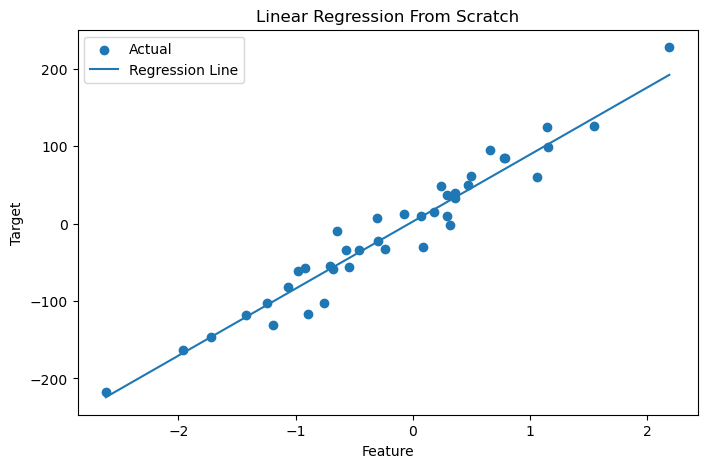

In [12]:
sorted_indices = np.argsort(X_test[:, 0])

X_sorted = X_test[sorted_indices]
y_sorted = y_pred[sorted_indices]

plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_sorted, y_sorted, label="Regression Line")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression From Scratch")

plt.legend()
plt.show()

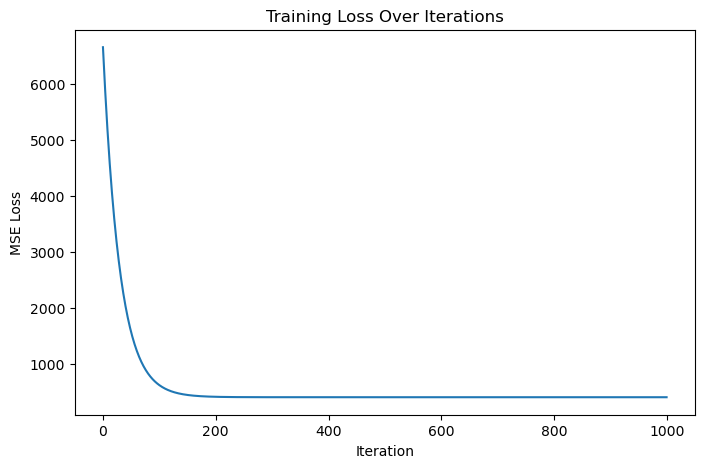

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Iterations")

plt.show()

In [14]:
sklearn_model = SklearnLinearRegression()

sklearn_model.fit(X_train, y_train)

sklearn_predictions = sklearn_model.predict(X_test)

In [15]:
scratch_mse = mean_squared_error(y_test, y_pred)
sklearn_mse = mean_squared_error(y_test, sklearn_predictions)

scratch_r2 = r2_score(y_test, y_pred)
sklearn_r2 = r2_score(y_test, sklearn_predictions)

print("From Scratch")
print("MSE:", scratch_mse)
print("R²:", scratch_r2)

print("\nScikit-Learn")
print("MSE:", sklearn_mse)
print("R²:", sklearn_r2)

From Scratch
MSE: 437.5498717360177
R²: 0.9449706567825913

Scikit-Learn
MSE: 437.54985402070196
R²: 0.9449706590105937


In [16]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression From Scratch",
        "Scikit-Learn Linear Regression"
    ],
    "MSE": [
        scratch_mse,
        sklearn_mse
    ],
    "R2 Score": [
        scratch_r2,
        sklearn_r2
    ]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression From Scratch,437.549872,0.944971
1,Scikit-Learn Linear Regression,437.549854,0.944971
